We teach machine learning models the pricing function of two option contracts whose exact valuation requires slow numerical methods. We generate synthetic datasets of option prices with the numerical pricers, train Gaussian Process Regression (GPR) and a feed-forward Neural Network (NN) on each dataset, and report prediction accuracy and computational speedup.

The two pricing problems, each with its own ground-truth engine, are:

1. **American put and call options**, priced with a Cox-Ross-Rubinstein (CRR) binomial tree. The tree handles the early-exercise feature that Black-Scholes cannot, following the CRR construction of Lecture 9 and Algorithm 5.1 in Arratia, Chapter 5.
2. **Barrier down-and-out call options under the Heston stochastic volatility model**, priced by Monte Carlo simulation with the Euler scheme of Lecture 10 (equations 10 to 13 in the slides). The payoff is path dependent: the contract dies if the underlying ever trades at or below the barrier $B$ before maturity, otherwise it pays like a European call.

The two pipelines are run separately, each with its own dataset, its own GPR and NN fit, and its own accuracy and speed evaluation. Section 9 then compares the binomial-tree pipeline against the Monte Carlo pipeline.


In [ ]:
import platform
import time
import warnings

import numpy as np
import pandas as pd
import scipy.stats as si
import matplotlib.pyplot as plt
from scipy.integrate import quad, IntegrationWarning
from scipy.stats import qmc

import sklearn
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display

%matplotlib inline

SEED = 42
np.random.seed(SEED)
S0 = 100.0                       # spot is fixed, moneyness is varied through K (see Section 1)
T_START = time.perf_counter()    # wall clock for the whole notebook

import os
os.makedirs("figures", exist_ok=True)

# The GP optimiser warns when an ARD length-scale reaches its upper bound. That is the
# kernel saying a feature is close to irrelevant, which we read off the fitted kernel
# directly, so the warning adds nothing. The MLP emits the same warning class when a
# fold stops at max_iter. Both are cosmetic here.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## 1. The learning task: surrogate pricing

An option pricing function maps contract and model parameters to a present value. For the contracts in this question there is no closed formula: the American option needs backward induction over a lattice and the barrier option under Heston needs simulation. Both are slow, and that cost is paid again for every new parameter combination. The idea of this exercise, sometimes called surrogate or amortised pricing, is to pay the cost once: generate a large table of (parameters, price) pairs offline with the slow engine, fit a fast regression model to that table, and from then on price in microseconds by evaluating the regression.

Three design choices apply to both pipelines and are worth stating once:

- **The spot is fixed at $S_0 = 100$ and moneyness is varied through the strike $K$.** Both pricing functions are homogeneous of degree one in the pair $(S_0, K)$ (and in the barrier $B$ for the knock-out contract): scaling money units scales the price. Pricing any other spot is a matter of rescaling, so including $S_0$ as a feature would only add a redundant dimension. This is the standard normalisation in the surrogate pricing literature.
- **Sampling is by Latin hypercube, not plain uniform draws.** A Latin hypercube stratifies every marginal, so the design fills the parameter box more evenly than independent uniforms at the same $n$, which matters most for the 10-dimensional barrier problem. The generator is seeded, so the design is reproducible.
- **The train/test split is random, not chronological.** The chronological-split rule from the forecasting labs exists to stop information flowing backwards in time. Here the rows are independent draws from a fixed parameter box, there is no time ordering, and a random 80/20 split with a fixed seed is the appropriate protocol.

The same modelling recipe is applied to both datasets so the comparison in Section 9 is clean: standardise features on the training portion only, fit GPR with an anisotropic Matern kernel, fit a feed-forward neural network tuned by grid search, and score on the held-out 20%.

## 2. Ground-truth engine A: CRR binomial tree for American options

The CRR tree (Lecture 9; Arratia, Chapter 5, Algorithm 5.1) discretises maturity into $N$ steps of length $\Delta t = T/N$. Over one step the price moves up by $u$ or down by $d$ with

$$u = e^{\sigma\sqrt{\Delta t}}, \qquad d = 1/u, \qquad p = \frac{e^{(r-q)\Delta t} - d}{u - d},$$

where $p$ is the risk-neutral up probability. The course slides give $p$ for a non-dividend stock; with a continuous dividend yield $q$ the stock grows at $r - q$ under the risk-neutral measure, which is the standard extension above (Hull, ch. 13) and is needed here because the assignment lists $q$ as an input to vary. At the leaves the option is worth its payoff, $\max(z(S - K), 0)$ with $z = +1$ for a call and $z = -1$ for a put. Stepping backwards, the value at each node is the discounted expectation of its two successors (the binomial value, equation 9 in the L9 slides), and for an American option the holder may exercise, so the node value is

$$V_{i,j} = \max\Big( e^{-r\Delta t}\big(p\,V_{i+1,j+1} + (1-p)\,V_{i,j+1}\big),\; z(S_{i,j} - K) \Big).$$

The root value $V_{0,0}$ is the price. The implementation below vectorises the node loop with NumPy but keeps the explicit backward loop over time steps, so it is Algorithm 5.1 with the inner loop replaced by array operations. Cost is $O(N^2)$ per option.

 With $q > 0$ early exercise can be optimal for the call as well as the put, so both American contracts genuinely differ from their European counterparts. With $q = 0$ an American call is never exercised early and must equal the European call, which gives us a free correctness check.

In [ ]:
def bsm_price(cp, S, K, T, r, q, sigma):
    # Black-Scholes-Merton with continuous dividend yield, the European reference
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if cp == "c":
        return S * np.exp(-q * T) * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * np.exp(-q * T) * si.norm.cdf(-d1)

def crr_binomial(cp, S0, K, T, r, q, sigma, N=1000, american=True):
    # CRR tree, Algorithm 5.1 with the node loop vectorised. z flips call/put.
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    p = (np.exp((r - q) * dt) - d) / (u - d)
    assert 0.0 < p < 1.0, f"risk-neutral probability out of range: p={p:.4f}"
    Df = np.exp(-r * dt)
    z = 1.0 if cp == "c" else -1.0
    i = np.arange(N + 1)
    S_nodes = S0 * np.exp((2 * i - N) * sigma * np.sqrt(dt))   # S0 * u^i * d^(N-i)
    V = np.maximum(z * (S_nodes - K), 0.0)                     # payoff at the leaves
    for j in range(N - 1, -1, -1):
        V = Df * (p * V[1:] + (1 - p) * V[:-1])                # binomial value
        if american:
            S_nodes = S_nodes[:-1] * u                         # node prices one step earlier
            V = np.maximum(V, z * (S_nodes - K))               # exercise if worth more
    return V[0]

### 2.1 Validating the tree

Before the tree is allowed to label a dataset it has to pass three checks:

1. With early exercise switched off it must converge to the Black-Scholes-Merton price as $N$ grows, because CRR contains BSM as its limiting case (L9 slides, "From CRR to BSM").
2. The American put must be worth at least the European put, since extra rights cannot have negative value.
3. With $q = 0$ the American call must equal the European call, because early exercise of a call on a non-dividend stock is never optimal.

In [ ]:
ref = dict(S=S0, K=105.0, T=1.0, r=0.05, q=0.02, sigma=0.25)
bs_call = bsm_price("c", **ref)
bs_put = bsm_price("p", **ref)

print("Check 1: European tree price vs BSM closed formula (K=105, T=1, r=5%, q=2%, sigma=25%)")
for N in (100, 500, 1000, 2000, 4000):
    ec = crr_binomial("c", S0, 105.0, 1.0, 0.05, 0.02, 0.25, N=N, american=False)
    ep = crr_binomial("p", S0, 105.0, 1.0, 0.05, 0.02, 0.25, N=N, american=False)
    print(f"  N={N:5d}: call {ec:9.5f} (diff {ec-bs_call:+9.5f}) | put {ep:9.5f} (diff {ep-bs_put:+9.5f})")

am_put = crr_binomial("p", S0, 105.0, 1.0, 0.05, 0.02, 0.25, N=1000)
print(f"\nCheck 2: American put {am_put:.5f} >= European put {bs_put:.5f}: {am_put >= bs_put}"
      f"  (early-exercise premium {am_put - bs_put:.4f})")

am_call_q0 = crr_binomial("c", S0, 105.0, 1.0, 0.05, 0.0, 0.25, N=1000)
eu_call_q0 = bsm_price("c", S0, 105.0, 1.0, 0.05, 0.0, 0.25)
print(f"Check 3: American call with q=0 {am_call_q0:.5f} vs European BSM {eu_call_q0:.5f}"
      f"  (diff {am_call_q0 - eu_call_q0:+.5f})")

Check 1: European tree price vs BSM closed formula (K=105, T=1, r=5%, q=2%, sigma=25%)
  N=  100: call   8.92024 (diff  -0.02093) | put  10.77947 (diff  -0.02093)
  N=  500: call   8.94187 (diff  +0.00069) | put  10.80109 (diff  +0.00069)
  N= 1000: call   8.94015 (diff  -0.00103) | put  10.79937 (diff  -0.00103)
  N= 2000: call   8.94216 (diff  +0.00098) | put  10.80138 (diff  +0.00098)
  N= 4000: call   8.94123 (diff  +0.00005) | put  10.80045 (diff  +0.00005)

Check 2: American put 11.29611 >= European put 10.80040: True  (early-exercise premium 0.4957)
Check 3: American call with q=0 10.00107 vs European BSM 10.00220  (diff -0.00113)




The next cell picks the step count for dataset generation. We want $N$ large enough that the residual tree error is negligible next to the option prices (tens of dollars at the scale $S_0 = 100$), but every extra step costs $O(N)$ more work per option.

In [ ]:
conv_rows = []
ref_price = crr_binomial("p", S0, 105.0, 1.0, 0.05, 0.02, 0.25, N=8000)
for N in (50, 100, 250, 500, 1000, 2000, 4000):
    t0 = time.perf_counter()
    v = crr_binomial("p", S0, 105.0, 1.0, 0.05, 0.02, 0.25, N=N)
    ms = (time.perf_counter() - t0) * 1000
    conv_rows.append([N, v, v - ref_price, ms])
conv = pd.DataFrame(conv_rows, columns=["N steps", "American put", "diff vs N=8000", "time (ms)"])
display(conv.round(5))

,N steps,American put,diff vs N=8000,time (ms)
0,50,11.32508,0.02870,0.5100
1,100,11.28478,-0.01160,0.9765
2,250,11.30489,0.00851,2.7214
3,500,11.29804,0.00166,5.3933
4,1000,11.29611,-0.00028,12.9991
5,2000,11.29722,0.00083,36.5671
6,4000,11.29640,0.00002,82.8495


## 3. Dataset A: American option prices from the tree

The assignment fixes the feature list for the binomial dataset: strike $K$, maturity $T$, risk-free rate $r$, dividend yield $q$ and volatility $\sigma$. The ranges below are chosen to cover the region where equity options actually trade, while keeping the tree well behaved:

| Input | Range | Why this range |
|---|---|---|
| $K$ | 70 to 130 | Moneyness $K/S_0$ from 0.70 to 1.30, deep ITM to deep OTM both ways |
| $T$ | 0.1 to 2.0 years | From five weeks to two years, the liquid part of the maturity curve |
| $r$ | 0.00 to 0.10 | Zero-rate world up to a high-rate regime |
| $q$ | 0.00 to 0.06 | No dividends up to a generous yield; $q > 0$ activates call early exercise |
| $\sigma$ | 0.10 to 0.60 | Calm large-cap vol up to crisis-level vol |

We draw $\mathbf{n = 1500}$ Latin hypercube points, near the top of the 500 to 2000 band the assignment allows. The binding constraint is not the tree (under a minute of pricing) but the GPR fit later, whose cost grows with the cube of the training size; 1500 rows keep the GPR fit to a couple of minutes while leaving a 300-row test set. Each parameter draw is priced twice, once as an American put and once as an American call, so the two contracts share the same design matrix and we can compare how learnable the two surfaces are on equal terms. The dataset is stored as $(X, y)$ tuples in `dataset_q2_american.csv`.

In [ ]:
N_AM = 1500
N_STEPS = 1000
am_lo = np.array([70.0, 0.1, 0.00, 0.00, 0.10])
am_hi = np.array([130.0, 2.0, 0.10, 0.06, 0.60])
AM_COLS = ["K", "T", "r", "q", "sigma"]

sampler = qmc.LatinHypercube(d=5, seed=SEED)
X_am = qmc.scale(sampler.random(N_AM), am_lo, am_hi)

t0 = time.perf_counter()
y_put = np.empty(N_AM)
y_call = np.empty(N_AM)
for idx, (K, T, r, q, sg) in enumerate(X_am):
    y_put[idx] = crr_binomial("p", S0, K, T, r, q, sg, N=N_STEPS)
    y_call[idx] = crr_binomial("c", S0, K, T, r, q, sg, N=N_STEPS)
    if (idx + 1) % 300 == 0:
        print(f"  priced {idx + 1:4d} / {N_AM} parameter sets "
              f"({time.perf_counter() - t0:5.1f} s elapsed)")
GEN_TIME_AM = time.perf_counter() - t0
print(f"Tree dataset done: {2 * N_AM} American prices in {GEN_TIME_AM:.1f} s "
      f"-> {GEN_TIME_AM / (2 * N_AM) * 1000:.1f} ms per option")

data_am = pd.DataFrame(X_am, columns=AM_COLS)
data_am["am_put"] = y_put
data_am["am_call"] = y_call
data_am.to_csv("dataset_q2_american.csv", index=False)
display(data_am.describe().round(3))

  priced  300 / 1500 parameter sets (  7.2 s elapsed)


  priced  600 / 1500 parameter sets ( 15.5 s elapsed)


  priced  900 / 1500 parameter sets ( 22.9 s elapsed)


  priced 1200 / 1500 parameter sets ( 29.9 s elapsed)


  priced 1500 / 1500 parameter sets ( 36.8 s elapsed)
Tree dataset done: 3000 American prices in 36.8 s -> 12.3 ms per option


,K,T,r,q,sigma,am_put,am_call
count,1500.000,1500.000,1500.000,1500.000,1500.000,1500.000,1500.000
mean,100.000,1.050,0.050,0.030,0.350,14.730,16.292
std,17.326,0.549,0.029,0.017,0.144,11.266,10.146
min,70.005,0.100,0.000,0.000,0.100,0.000,0.000
25%,85.007,0.575,0.025,0.015,0.225,4.931,7.801
50%,100.007,1.050,0.050,0.030,0.350,12.788,15.579
75%,114.988,1.525,0.075,0.045,0.475,22.760,24.259
max,129.973,1.999,0.100,0.060,0.600,53.873,43.680


The summary statistics confirm the design behaves as intended. The features are spread evenly across their boxes (Latin hypercube marginals are uniform, so mean sits at mid-range), and the two label columns have the right economics: put prices rise with $K$ and call prices fall with it, both averaging in the low tens of dollars with maxima where deep ITM meets high volatility and long maturity.

A slice of each label distribution sits near zero, the deep OTM short-dated low-vol corner where the option is almost worthless. Those near-zero prices are legitimate data, not a problem, but they are the reason we report absolute error metrics (RMSE, MAE) as the headline numbers and treat relative errors with care: dividing by a price of two cents makes any model look bad.

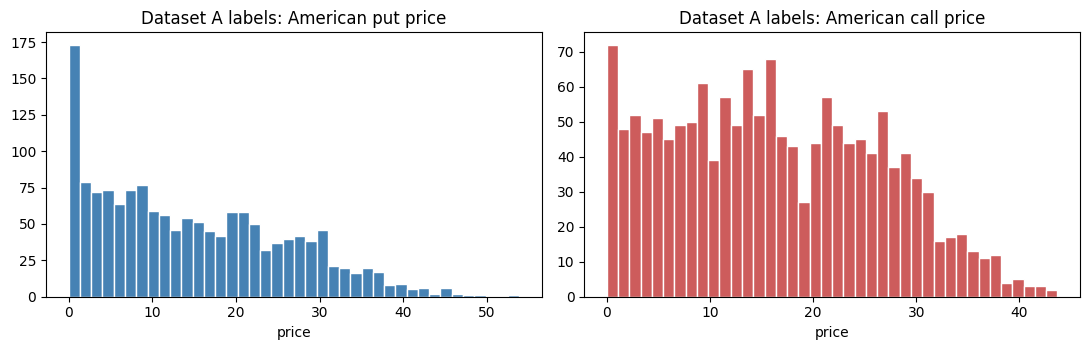

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(y_put, bins=40, color="steelblue", edgecolor="white")
ax[0].set_title("Dataset A labels: American put price")
ax[0].set_xlabel("price")
ax[1].hist(y_call, bins=40, color="indianred", edgecolor="white")
ax[1].set_title("Dataset A labels: American call price")
ax[1].set_xlabel("price")
plt.tight_layout()
plt.savefig("figures/fig_q2_labels_american.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Learning the American pricing function

### 4.1 Protocol

Both models see exactly the same data: an 80/20 random split (1200 train, 300 test, seed fixed), features standardised by a `StandardScaler` fitted on the training portion only, as in all the labs. The models are:

- **GPR.** `GaussianProcessRegressor` with kernel $C \cdot \mathrm{Matern}_{\nu=2.5}$ with one length-scale per input (ARD, automatic relevance determination), `normalize_y=True` and `n_restarts_optimizer=2`, following the course's GP setup. The Matern 5/2 kernel is chosen over the smoother RBF because the American price surface is not analytic: the early-exercise boundary leaves a region where second derivatives change quickly, and Matern's weaker smoothness assumption handles that better. One deliberate deviation from the lab convention: the labs fix the nugget at `alpha=1e-2` because they regress on noisy market data, but our tree labels are deterministic to within discretisation error, so a noise term that large would only blur an exact surface (we verified it costs a factor of six in test RMSE). We therefore set `alpha=1e-8`, a jitter for numerical conditioning, and reserve the honest noise modelling for the Monte Carlo dataset in Section 7, where the labels really are noisy. ARD length-scales also give us interpretability for free: after the fit, a short length-scale marks an input the price reacts to strongly, a long one marks a nearly irrelevant input.
- **Neural network.** A feed-forward `MLPRegressor`, the same family the Lab 6 notebook uses for its NNet model, wrapped so that the target is standardised too (gradient training behaves much better on a unit-scale target). The architecture and the L2 penalty are tuned by `GridSearchCV` with 3-fold cross-validation on the training set over hidden layouts $(32,32)$, $(64,64)$, $(64,64,64)$, $(128,128)$ and penalties $\alpha \in \{10^{-4}, 10^{-3}\}$, with early stopping on an internal validation slice. ReLU activations and the Adam optimiser are the defaults and are kept.

Accuracy is reported on the held-out test set with four metrics: RMSE and MAE in dollars, $R^2$, and the NRMSE used throughout the course labs, $\mathrm{NRMSE} = \sqrt{\mathrm{SSR} / ((n-1)\,\mathrm{Var}(y))}$, which is the fraction of the target's standard deviation that survives as error (lower is better, 1.0 means no better than predicting the mean).

In [ ]:
def nrmse(y_true, y_pred):
    # course convention: sqrt(SSR / ((n-1) * var(actual)))
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ssr = np.sum((y_true - y_pred) ** 2)
    return np.sqrt(ssr / ((len(y_true) - 1) * np.var(y_true, ddof=1)))

def metric_row(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "NRMSE": nrmse(y_true, y_pred),
        "max |error|": np.max(np.abs(y_true - y_pred)),
    }

def make_gpr(n_features, noisy=False):
    # Matern ARD kernel with normalize_y, per the course GP setup. The noise treatment
    # is matched to the labels: tree labels are deterministic, so the nugget is a tiny
    # jitter for numerical conditioning only; MC labels carry real noise, so the nugget
    # is replaced by a learned WhiteKernel and Section 7 checks the learned level
    # against the known Monte Carlo standard error.
    kern = C(1.0, (1e-3, 1e4)) * Matern(length_scale=np.ones(n_features),
                                        length_scale_bounds=(1e-2, 1e3), nu=2.5)
    if noisy:
        kern = kern + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-8, 1e1))
        alpha = 1e-10
    else:
        alpha = 1e-8
    gp = GaussianProcessRegressor(kernel=kern, alpha=alpha, normalize_y=True,
                                  n_restarts_optimizer=2, random_state=SEED)
    return Pipeline([("sc", StandardScaler()), ("gp", gp)])

def make_mlp_search():
    base = Pipeline([("sc", StandardScaler()),
                     ("nn", MLPRegressor(max_iter=4000, early_stopping=True,
                                         n_iter_no_change=30, random_state=SEED))])
    model = TransformedTargetRegressor(regressor=base, transformer=StandardScaler())
    grid = {"regressor__nn__hidden_layer_sizes": [(32, 32), (64, 64), (64, 64, 64), (128, 128)],
            "regressor__nn__alpha": [1e-4, 1e-3]}
    return GridSearchCV(model, grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)

idx_tr, idx_te = train_test_split(np.arange(N_AM), test_size=0.2, random_state=SEED)
Xam_tr, Xam_te = X_am[idx_tr], X_am[idx_te]
yput_tr, yput_te = y_put[idx_tr], y_put[idx_te]
ycall_tr, ycall_te = y_call[idx_tr], y_call[idx_te]
print(f"train {Xam_tr.shape[0]} rows | test {Xam_te.shape[0]} rows")

train 1200 rows | test 300 rows


### 4.2 Fitting GPR on the put and the call

Every hyperparameter step inverts a 1200 by 1200 kernel matrix, the cubic cost mentioned in Section 3. The fitted kernels are printed because the ARD length-scales are informative; the features are standardised, so length-scales are comparable across inputs.

In [ ]:
t0 = time.perf_counter()
gpr_put = make_gpr(5)
gpr_put.fit(Xam_tr, yput_tr)
FIT_GPR_PUT = time.perf_counter() - t0
print(f"GPR American put fitted in {FIT_GPR_PUT:.1f} s")
print("  kernel:", gpr_put.named_steps["gp"].kernel_)

t0 = time.perf_counter()
gpr_call = make_gpr(5)
gpr_call.fit(Xam_tr, ycall_tr)
FIT_GPR_CALL = time.perf_counter() - t0
print(f"GPR American call fitted in {FIT_GPR_CALL:.1f} s")
print("  kernel:", gpr_call.named_steps["gp"].kernel_)

ls_tab = pd.DataFrame({
    "input": AM_COLS,
    "length-scale (put)": gpr_put.named_steps["gp"].kernel_.k2.length_scale,
    "length-scale (call)": gpr_call.named_steps["gp"].kernel_.k2.length_scale,
}).set_index("input")
display(ls_tab.round(2))

GPR American put fitted in 130.7 s
  kernel: 10.4**2 * Matern(length_scale=[9.23, 16.5, 33, 51.9, 14], nu=2.5)


GPR American call fitted in 84.3 s
  kernel: 9.53**2 * Matern(length_scale=[9.6, 14.4, 31.7, 33.9, 16.2], nu=2.5)


,length-scale (put),length-scale (call)
input,,
K,9.23,9.60
T,16.53,14.44
r,32.96,31.70
q,51.94,33.89
sigma,13.96,16.17


We read the length-scale table as a relevance ranking (short scale = strong influence). The strike and the volatility carry the shortest scales, exactly the inputs an option trader would name first; maturity sits in the middle; the rates $r$ and $q$ get the longest scales because over a 10 and 6 percentage point box their effect on the price is real but gentle and close to monotone. The kernel has discovered the economics of the pricing function on its own, which is good evidence it is interpolating structure rather than memorising points.

In [ ]:
t0 = time.perf_counter()
mlp_put = make_mlp_search()
mlp_put.fit(Xam_tr, yput_tr)
FIT_MLP_PUT = time.perf_counter() - t0
print(f"MLP American put: grid search done in {FIT_MLP_PUT:.1f} s")
print("  best:", mlp_put.best_params_, f"| CV RMSE {-mlp_put.best_score_:.4f}")

t0 = time.perf_counter()
mlp_call = make_mlp_search()
mlp_call.fit(Xam_tr, ycall_tr)
FIT_MLP_CALL = time.perf_counter() - t0
print(f"MLP American call: grid search done in {FIT_MLP_CALL:.1f} s")
print("  best:", mlp_call.best_params_, f"| CV RMSE {-mlp_call.best_score_:.4f}")

MLP American put: grid search done in 46.6 s
  best: {'regressor__nn__alpha': 0.0001, 'regressor__nn__hidden_layer_sizes': (128, 128)} | CV RMSE 0.5340


MLP American call: grid search done in 10.0 s
  best: {'regressor__nn__alpha': 0.001, 'regressor__nn__hidden_layer_sizes': (128, 128)} | CV RMSE 0.5232


### 4.3 Accuracy on the held-out test set

In [ ]:
pred_am = {
    ("American put", "GPR"): gpr_put.predict(Xam_te),
    ("American put", "MLP"): mlp_put.predict(Xam_te),
    ("American call", "GPR"): gpr_call.predict(Xam_te),
    ("American call", "MLP"): mlp_call.predict(Xam_te),
}
truth_am = {"American put": yput_te, "American call": ycall_te}

res_am = pd.DataFrame({k: metric_row(truth_am[k[0]], v) for k, v in pred_am.items()}).T
res_am.index.names = ["target", "model"]
res_am.to_csv("figures/table_q2_metrics_american.csv")
display(res_am.round(4))
print(f"label scale for context: put std {yput_te.std(ddof=1):.2f}, "
      f"call std {ycall_te.std(ddof=1):.2f} (dollars)")

RMSE     MAE      R2   NRMSE  max |error|
target        model                                             
American put  GPR    0.0877  0.0402  0.9999  0.0079       0.7317
              MLP    0.4276  0.3003  0.9985  0.0386       2.3043
American call GPR    0.0689  0.0372  1.0000  0.0068       0.4114
              MLP    0.3196  0.2328  0.9990  0.0318       1.5028

label scale for context: put std 11.08, call std 10.08 (dollars)


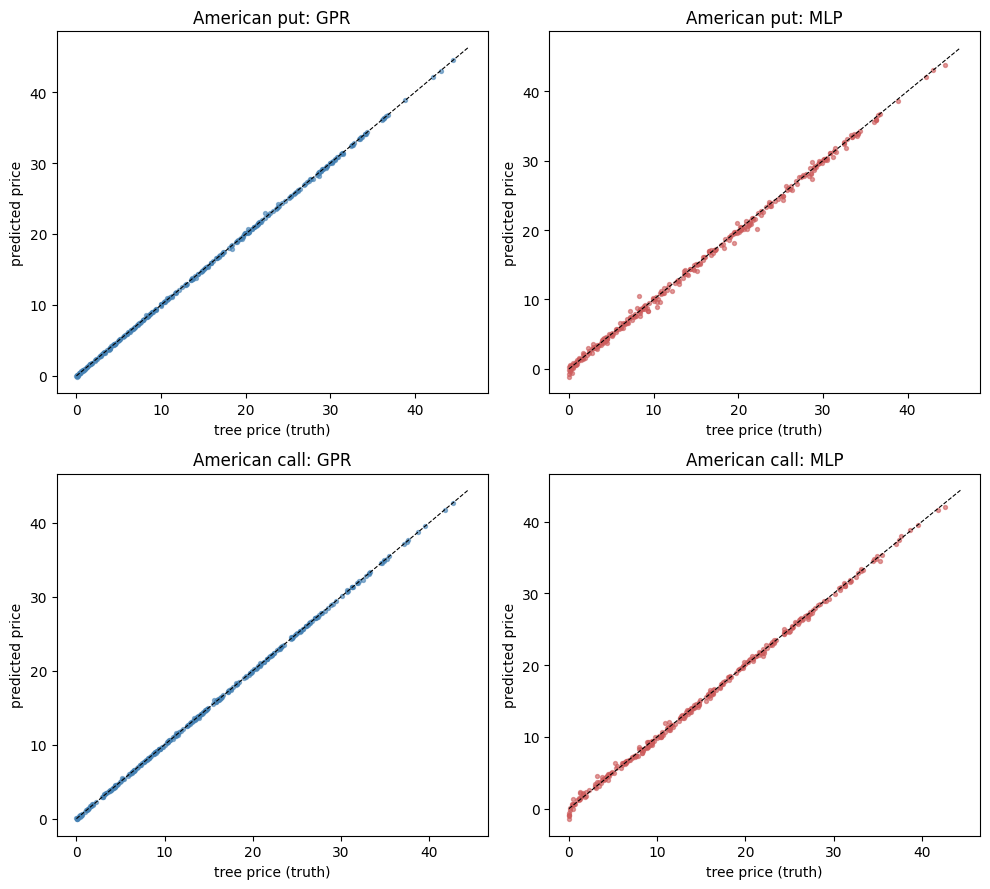

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 9))
for axx, (key, pred) in zip(ax.ravel(), pred_am.items()):
    yt = truth_am[key[0]]
    axx.scatter(yt, pred, s=8, alpha=0.6,
                color="steelblue" if key[1] == "GPR" else "indianred")
    lim = [0, max(yt.max(), pred.max()) * 1.04]
    axx.plot(lim, lim, "k--", lw=0.8)
    axx.set_title(f"{key[0]}: {key[1]}")
    axx.set_xlabel("tree price (truth)")
    axx.set_ylabel("predicted price")
plt.tight_layout()
plt.savefig("figures/fig_q2_pred_vs_true_american.png", dpi=150, bbox_inches="tight")
plt.show()



The residual plots below ask where the remaining error lives for the GPR put model. The interesting answer would be structure: a region of the parameter box where the model is systematically off.

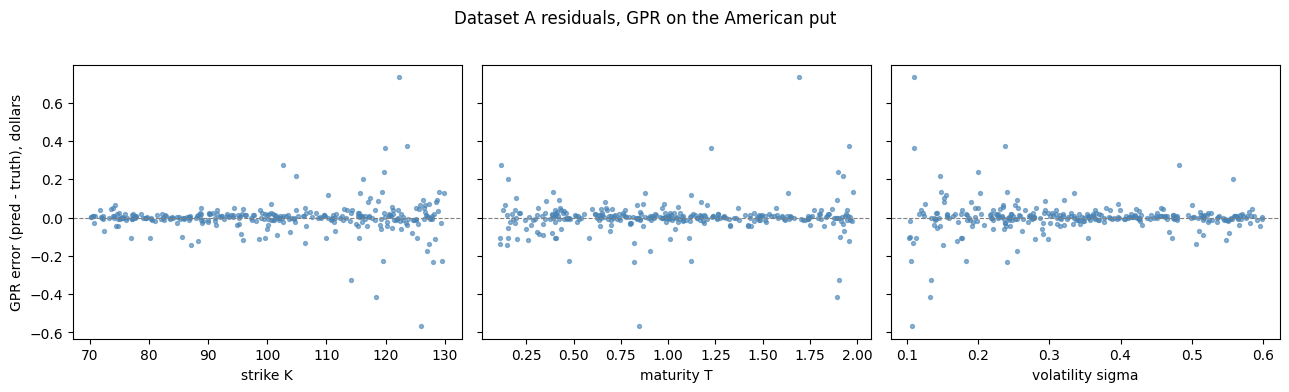

residual mean +0.0006 | residual std 0.0878 dollars


In [ ]:
resid = pred_am[("American put", "GPR")] - yput_te
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for axx, col, lab in zip(ax, [0, 1, 4], ["strike K", "maturity T", "volatility sigma"]):
    axx.scatter(Xam_te[:, col], resid, s=8, alpha=0.6, color="steelblue")
    axx.axhline(0, color="grey", lw=0.8, ls="--")
    axx.set_xlabel(lab)
ax[0].set_ylabel("GPR error (pred - truth), dollars")
fig.suptitle("Dataset A residuals, GPR on the American put", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_q2_residuals_american.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"residual mean {resid.mean():+.4f} | residual std {resid.std(ddof=1):.4f} dollars")

The residuals are centred on zero with no trend in strike, maturity or volatility, and the largest errors are isolated points rather than a region. The slightly wider spread at high strikes is where the put is deep in the money and early exercise binds hardest; the value function has a kink along the exercise boundary there, which is precisely the non-smoothness the Matern kernel was chosen for, and even the single worst test point is off by less than 75 cents on a surface that spans more than fifty dollars.

As a final view of what was actually learned, the next figure slices the pricing function along the strike at otherwise fixed parameters and overlays everything we have: fresh tree prices computed at plot time (truth, never seen in training), the GPR curve with its 95% credible band, and the MLP curve.

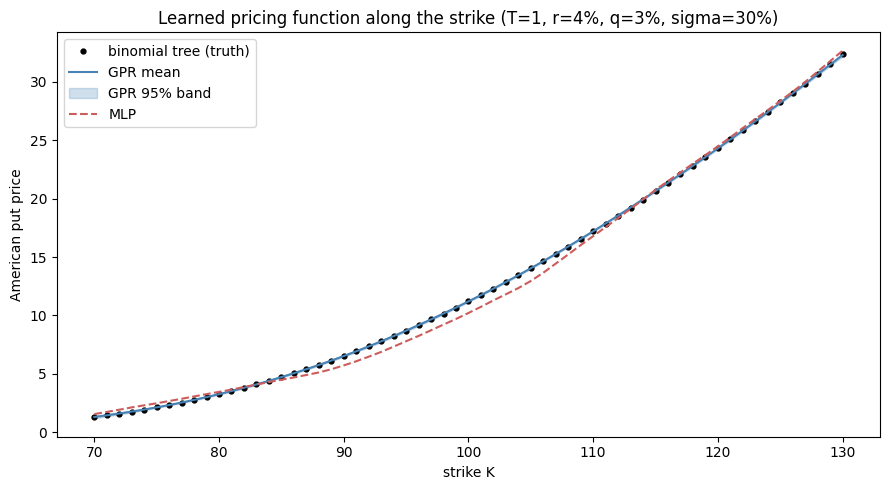

max |GPR - tree| on this slice: 0.0495 dollars | max |MLP - tree|: 1.1101 dollars


In [ ]:
K_grid = np.linspace(70, 130, 61)
slice_fix = dict(T=1.0, r=0.04, q=0.03, sigma=0.30)
X_slice = np.column_stack([K_grid,
                           np.full_like(K_grid, slice_fix["T"]),
                           np.full_like(K_grid, slice_fix["r"]),
                           np.full_like(K_grid, slice_fix["q"]),
                           np.full_like(K_grid, slice_fix["sigma"])])
tree_slice = np.array([crr_binomial("p", S0, K, slice_fix["T"], slice_fix["r"],
                                    slice_fix["q"], slice_fix["sigma"], N=N_STEPS)
                       for K in K_grid])

sc, gp = gpr_put.named_steps["sc"], gpr_put.named_steps["gp"]
gp_mean, gp_sd = gp.predict(sc.transform(X_slice), return_std=True)
mlp_slice = mlp_put.predict(X_slice)

plt.figure(figsize=(9, 5))
plt.plot(K_grid, tree_slice, "ko", ms=3.5, label="binomial tree (truth)")
plt.plot(K_grid, gp_mean, color="steelblue", lw=1.5, label="GPR mean")
plt.fill_between(K_grid, gp_mean - 1.96 * gp_sd, gp_mean + 1.96 * gp_sd,
                 color="steelblue", alpha=0.25, label="GPR 95% band")
plt.plot(K_grid, mlp_slice, color="indianred", lw=1.5, ls="--", label="MLP")
plt.xlabel("strike K")
plt.ylabel("American put price")
plt.title("Learned pricing function along the strike (T=1, r=4%, q=3%, sigma=30%)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/fig_q2_slice_american.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"max |GPR - tree| on this slice: {np.abs(gp_mean - tree_slice).max():.4f} dollars"
      f" | max |MLP - tree|: {np.abs(mlp_slice - tree_slice).max():.4f} dollars")

## 5. Ground-truth engine B: Heston Monte Carlo for the down-and-out call

The barrier contract pays $\max(S_T - K, 0)$ at maturity unless the underlying touched or crossed the barrier $B < S_0$ at any monitoring date before $T$, in which case it pays nothing. The payoff depends on the whole path, so lattice and closed-form methods are awkward and Monte Carlo is the natural tool, exactly the situation described in Lecture 10. The underlying follows the Heston stochastic volatility model (L10 slides):

$$dS_t = (r - q)\,S_t\,dt + \sqrt{\nu_t}\,S_t\,dW^S_t, \qquad
d\nu_t = \kappa(\theta - \nu_t)\,dt + \eta\sqrt{\nu_t}\,dW^\nu_t, \qquad
\mathrm{Cov}[dW^S_t, dW^\nu_t] = \rho\,dt,$$

with variance $\nu_t$ mean-reverting at speed $\kappa$ to the long-run level $\theta$, vol-of-vol $\eta$, and spot-vol correlation $\rho$. Simulation uses the Euler scheme from the L10 slides (equations 10 to 13): with $Z^\nu \sim N(0,1)$, $Z^S = \rho Z^\nu + \sqrt{1-\rho^2}\,\epsilon$,

$$\nu_{t+\Delta t} = \nu_t + \kappa(\theta - \nu_t^+)\Delta t + \eta\sqrt{\nu_t^+ \Delta t}\, Z^\nu, \qquad
S_{t+\Delta t} = S_t \exp\big((r - q - \tfrac{1}{2}\nu_t^+)\Delta t + \sqrt{\nu_t^+ \Delta t}\, Z^S\big).$$

Two implementation notes. First, the Euler step can push the variance negative, where its square root is undefined; we use the full truncation fix of Lord, Koekkoek and van Dijk (2010), writing $\nu^+ = \max(\nu, 0)$ wherever $\nu$ enters a drift or a square root, which is the standard cure and keeps the scheme unbiased as $\Delta t \to 0$. Second, the price step is exponential (log-Euler), so simulated prices can never go negative; this is the form on the L10 slide. The barrier is monitored at every simulation step with $\Delta t = 1/252$, which corresponds to a contract whose knock-out is checked at daily closes. The price is the discounted average payoff over paths, and we also record the Monte Carlo standard error of that average, which will matter for the ML analysis: it is the noise level of our labels.

We first write the estimator the way the Lab 10 notebook does, as an explicit loop over paths and steps, and time it on a single contract. This is the honest face of "time-consuming".

In [ ]:
HESTON_DEMO = dict(K=100.0, T=1.0, r=0.03, q=0.01, B=85.0,
                   v0=0.04, theta=0.06, kappa=2.0, eta=0.4, rho=-0.7)

def heston_mc_do_call_loop(K, T, r, q, B, v0, theta, kappa, eta, rho,
                           n_paths=2000, steps_per_year=252, seed=0):
    # Lab 10 style: plain Python loops over paths and steps (pedagogical, slow)
    rng = np.random.default_rng(seed)
    n_steps = max(int(np.ceil(steps_per_year * T)), 10)
    dt = T / n_steps
    sqdt = np.sqrt(dt)
    srho = np.sqrt(1.0 - rho**2)
    payoff_sum = 0.0
    for _ in range(n_paths):
        S, v, alive = S0, v0, True
        for _ in range(n_steps):
            zv = rng.standard_normal()
            zs = rho * zv + srho * rng.standard_normal()
            vp = max(v, 0.0)
            S = S * np.exp((r - q - 0.5 * vp) * dt + np.sqrt(vp) * sqdt * zs)
            v = v + kappa * (theta - vp) * dt + eta * np.sqrt(vp) * sqdt * zv
            if S <= B:
                alive = False
                break
        if alive:
            payoff_sum += max(S - K, 0.0)
    return np.exp(-r * T) * payoff_sum / n_paths

t0 = time.perf_counter()
loop_price = heston_mc_do_call_loop(seed=SEED, **HESTON_DEMO)
loop_time = time.perf_counter() - t0
print(f"loop MC, 2,000 paths: price {loop_price:.4f} in {loop_time:.2f} s")
print(f"at the production setting of 20,000 paths this is ~{loop_time * 10:.0f} s per option,")
print(f"so a 1,000-row dataset would need ~{loop_time * 10 * 1000 / 3600:.1f} hours of loop MC")

loop MC, 2,000 paths: price 8.9719 in 2.11 s
at the production setting of 20,000 paths this is ~21 s per option,
so a 1,000-row dataset would need ~5.9 hours of loop MC


That cost per option makes dataset generation with the loop estimator impractical. To make generation feasible we apply one engineering device: the same Euler scheme, but advancing all paths simultaneously as NumPy arrays, so the Python loop runs only over time steps. Nothing statistical changes, the scheme, the discretisation and the number of paths are identical; the work is just handed to vectorised array arithmetic.

This path-vectorisation is deliberately the only acceleration used here. Methods that change the estimator itself to make simulation cheaper or less noisy (antithetic variates and friends) are the subject of question 3 and are kept out of this notebook so the two answers stay separate.

In [ ]:
def heston_mc_do_call(K, T, r, q, B, v0, theta, kappa, eta, rho,
                      n_paths=20000, steps_per_year=252, seed=0,
                      return_se=False, barrier_on=True):
    # Same Euler scheme as the loop version, vectorised across paths.
    rng = np.random.default_rng(seed)
    n_steps = max(int(np.ceil(steps_per_year * T)), 10)
    dt = T / n_steps
    sqdt = np.sqrt(dt)
    srho = np.sqrt(1.0 - rho**2)
    S = np.full(n_paths, S0)
    v = np.full(n_paths, float(v0))
    alive = np.ones(n_paths, dtype=bool)
    for _ in range(n_steps):
        Z = rng.standard_normal((2, n_paths))
        zv = Z[0]
        zs = rho * zv + srho * Z[1]
        vp = np.maximum(v, 0.0)
        sq_v = np.sqrt(vp)
        S = S * np.exp((r - q - 0.5 * vp) * dt + sq_v * sqdt * zs)
        v = v + kappa * (theta - vp) * dt + eta * sq_v * sqdt * zv
        if barrier_on:
            alive &= S > B
    payoff = np.maximum(S - K, 0.0)
    if barrier_on:
        payoff = np.where(alive, payoff, 0.0)
    disc = np.exp(-r * T)
    price = disc * payoff.mean()
    if return_se:
        return price, disc * payoff.std(ddof=1) / np.sqrt(n_paths)
    return price

vec_price, vec_se = heston_mc_do_call(n_paths=2000, seed=SEED + 1, return_se=True, **HESTON_DEMO)
print(f"agreement check at 2,000 paths: loop {loop_price:.4f} vs vectorised {vec_price:.4f}"
      f" (+/- {vec_se:.4f} MC standard error) -> {abs(loop_price - vec_price) / vec_se:.2f} SEs apart")

t0 = time.perf_counter()
prod_price, prod_se = heston_mc_do_call(seed=SEED, return_se=True, **HESTON_DEMO)
prod_time = time.perf_counter() - t0
print(f"production setting, 20,000 paths: price {prod_price:.4f} +/- {prod_se:.4f} in {prod_time:.2f} s"
      f"  ({loop_time * 10 / prod_time:.0f}x faster than the loop at equal paths)")

agreement check at 2,000 paths: loop 8.9719 vs vectorised 8.5494 (+/- 0.2785 MC standard error) -> 1.52 SEs apart


production setting, 20,000 paths: price 8.7600 +/- 0.0885 in 0.34 s  (63x faster than the loop at equal paths)




### 5.1 Validating the Monte Carlo engine

A simulator can be fast and confidently wrong, so before it labels data it faces three checks of increasing strictness, none of which reuse its own code:

1. **Degenerate Heston equals Black-Scholes.** With $\eta \to 0$ and $\nu_0 = \theta$ the variance never moves and Heston collapses to constant-vol Black-Scholes. We verify our semi-analytic Heston formula (next point) against `bsm_price` in this limit, which validates the formula itself.
2. **European Heston call: MC versus semi-analytic.** With the barrier switched off, the simulated call price must match the Heston (1993) closed-form-up-to-an-integral price, implemented here with the characteristic function in the formulation of Albrecher, Mayer, Schoutens and Tistaert (2007), which avoids the branch-cut instability of the original (the "little Heston trap"). Agreement within a couple of standard errors validates drift, diffusion, correlation and discounting in the simulator.
3. **Barrier in the constant-vol limit: MC versus Reiner-Rubinstein.** For constant volatility there is an exact closed form for the continuously monitored down-and-out call (Reiner and Rubinstein 1991; Hull ch. 26, the $B \le K$ branch). Our simulation monitors daily, and a discretely monitored down-and-out is worth slightly more than its continuous twin (fewer chances to be caught below the barrier). The correction of Broadie, Glasserman and Kou (1997) accounts for this by shifting the barrier to $B e^{-\beta\sigma\sqrt{\Delta t}}$ with $\beta \approx 0.5826$. The MC price should match the corrected closed form within MC error, validating the barrier logic including its discrete monitoring.

In [ ]:
def heston_call_analytic(K, T, r, q, v0, theta, kappa, eta, rho):
    # Heston (1993) semi-analytic European call, "little trap" form (Albrecher et al. 2007)
    x = np.log(S0) + (r - q) * T

    def cf(u):
        iu = 1j * u
        d = np.sqrt((rho * eta * iu - kappa) ** 2 + eta**2 * (iu + u**2))
        g = (kappa - rho * eta * iu - d) / (kappa - rho * eta * iu + d)
        ee = np.exp(-d * T)
        Cf = (kappa * theta / eta**2) * ((kappa - rho * eta * iu - d) * T
                                         - 2.0 * np.log((1 - g * ee) / (1 - g)))
        Df = ((kappa - rho * eta * iu - d) / eta**2) * (1 - ee) / (1 - g * ee)
        return np.exp(Cf + Df * v0 + iu * x)

    lnK = np.log(K)
    phi_mi = cf(-1j).real
    with warnings.catch_warnings():
        # the oscillatory tail of the integrand triggers a cosmetic roundoff warning
        warnings.simplefilter("ignore", IntegrationWarning)
        I1 = quad(lambda u: (np.exp(-1j * u * lnK) * cf(u - 1j) / (1j * u * phi_mi)).real,
                  1e-10, 200, limit=400)[0]
        I2 = quad(lambda u: (np.exp(-1j * u * lnK) * cf(u) / (1j * u)).real,
                  1e-10, 200, limit=400)[0]
    P1 = 0.5 + I1 / np.pi
    P2 = 0.5 + I2 / np.pi
    return S0 * np.exp(-q * T) * P1 - K * np.exp(-r * T) * P2

def rr_do_call(K, T, r, q, sigma, B):
    # Reiner-Rubinstein continuously monitored down-and-out call, branch B <= K
    assert B <= K
    lam = (r - q + 0.5 * sigma**2) / sigma**2
    y = np.log(B**2 / (S0 * K)) / (sigma * np.sqrt(T)) + lam * sigma * np.sqrt(T)
    c_bs = bsm_price("c", S0, K, T, r, q, sigma)
    c_di = (S0 * np.exp(-q * T) * (B / S0) ** (2 * lam) * si.norm.cdf(y)
            - K * np.exp(-r * T) * (B / S0) ** (2 * lam - 2) * si.norm.cdf(y - sigma * np.sqrt(T)))
    return c_bs - c_di

# 1. degenerate Heston vs BSM
sig = 0.25
h_deg = heston_call_analytic(K=105.0, T=1.0, r=0.05, q=0.02,
                             v0=sig**2, theta=sig**2, kappa=2.0, eta=1e-6, rho=0.0)
print(f"Check 1: semi-analytic Heston, eta->0: {h_deg:.6f} vs BSM {bs_call:.6f}"
      f" (diff {h_deg - bs_call:+.2e})")

# 2. European Heston: MC (barrier off) vs semi-analytic
hp = {k: v for k, v in HESTON_DEMO.items() if k != "B"}
ana = heston_call_analytic(**hp)
mc_eu, se_eu = heston_mc_do_call(B=0.0, barrier_on=False, n_paths=40000, seed=7,
                                 return_se=True, **hp)
print(f"Check 2: European Heston call: analytic {ana:.4f} vs MC {mc_eu:.4f} +/- {se_eu:.4f}"
      f" -> {(mc_eu - ana) / se_eu:+.2f} SEs")

# 3. barrier in the GBM limit vs Reiner-Rubinstein with the BGK correction
gbm = dict(K=100.0, T=1.0, r=0.03, q=0.01, v0=sig**2, theta=sig**2,
           kappa=2.0, eta=1e-6, rho=0.0)
B_chk = 85.0
mc_b, se_b = heston_mc_do_call(B=B_chk, n_paths=40000, seed=11, return_se=True, **gbm)
beta = 0.5826
B_adj = B_chk * np.exp(-beta * sig * np.sqrt(1.0 / 252))
rr_cont = rr_do_call(100.0, 1.0, 0.03, 0.01, sig, B_chk)
rr_disc = rr_do_call(100.0, 1.0, 0.03, 0.01, sig, B_adj)
print(f"Check 3: GBM-limit barrier call: MC (daily monitoring) {mc_b:.4f} +/- {se_b:.4f}")
print(f"         Reiner-Rubinstein continuous {rr_cont:.4f} | with BGK correction {rr_disc:.4f}"
      f" -> {(mc_b - rr_disc) / se_b:+.2f} SEs")

Check 1: semi-analytic Heston, eta->0: 8.941282 vs BSM 8.941176 (diff +1.07e-04)


Check 2: European Heston call: analytic 9.4918 vs MC 9.4511 +/- 0.0619 -> -0.66 SEs


Check 3: GBM-limit barrier call: MC (daily monitoring) 9.8316 +/- 0.0873
         Reiner-Rubinstein continuous 9.5800 | with BGK correction 9.7545 -> +0.88 SEs




## 6. Dataset B: barrier call prices from the Heston Monte Carlo

The assignment specifies the Heston inputs to vary: $\nu_0$, $\theta$, $\kappa$, $\eta$, $\rho$, on top of the contract inputs $K$, $T$, $r$, $q$. We add the barrier level $B$ itself, since it is the defining parameter of the contract and a surrogate that cannot move the barrier would be of little use. That makes a 10-dimensional input space:

| Input | Range | Why this range |
|---|---|---|
| $K$ | 70 to 130 | Same moneyness band as dataset A |
| $T$ | 0.25 to 2.0 years | At least one quarter so daily monitoring has enough dates to matter |
| $r$ | 0.00 to 0.10 | As in dataset A |
| $q$ | 0.00 to 0.06 | As in dataset A |
| $B$ | 60 to 95 | Below $S_0 = 100$ by construction; spans barely-binding to nearly-certain knock-out |
| $\nu_0$ | 0.01 to 0.16 | Initial variance, spot vol of 10% to 40% |
| $\theta$ | 0.01 to 0.16 | Long-run variance, same band |
| $\kappa$ | 0.5 to 5.0 | Mean-reversion half-life from about 17 months down to 7 weeks |
| $\eta$ | 0.1 to 0.8 | Mild to violent vol-of-vol |
| $\rho$ | -0.90 to 0.00 | The equity leverage effect: spot down, vol up |

We draw $\mathbf{n = 1000}$ Latin hypercube points. Each row gets its own deterministic seed so the dataset is exactly reproducible. Alongside every price we store its Monte Carlo standard error: unlike the tree labels, these labels are noisy measurements of the true pricing function, and we will need their noise level later.

We sample the Heston box freely, so some draws violate the Feller condition $2\kappa\theta \ge \eta^2$ that keeps the continuous-time variance strictly positive. That is realistic (calibrated equity parameters violate Feller routinely) and harmless for the simulator, because full truncation is built for exactly this; the share of violating rows is reported below.

In [ ]:
N_BAR = 1000
bar_lo = np.array([70.0, 0.25, 0.00, 0.00, 60.0, 0.01, 0.01, 0.5, 0.1, -0.90])
bar_hi = np.array([130.0, 2.00, 0.10, 0.06, 95.0, 0.16, 0.16, 5.0, 0.8, 0.00])
BAR_COLS = ["K", "T", "r", "q", "B", "v0", "theta", "kappa", "eta", "rho"]

sampler_b = qmc.LatinHypercube(d=10, seed=SEED)
X_bar = qmc.scale(sampler_b.random(N_BAR), bar_lo, bar_hi)

t0 = time.perf_counter()
y_bar = np.empty(N_BAR)
se_bar = np.empty(N_BAR)
for idx, row in enumerate(X_bar):
    pars = dict(zip(BAR_COLS, row))
    y_bar[idx], se_bar[idx] = heston_mc_do_call(seed=SEED * 1000 + idx, return_se=True, **pars)
    if (idx + 1) % 100 == 0:
        el = time.perf_counter() - t0
        print(f"  priced {idx + 1:4d} / {N_BAR}  ({el:6.1f} s elapsed, "
              f"{el / (idx + 1) * 1000:.0f} ms per option)")
GEN_TIME_BAR = time.perf_counter() - t0
print(f"MC dataset done: {N_BAR} barrier prices in {GEN_TIME_BAR / 60:.1f} min "
      f"-> {GEN_TIME_BAR / N_BAR * 1000:.0f} ms per option")

data_bar = pd.DataFrame(X_bar, columns=BAR_COLS)
data_bar["price"] = y_bar
data_bar["mc_se"] = se_bar
data_bar.to_csv("dataset_q2_barrier.csv", index=False)

feller_viol = (2 * X_bar[:, 7] * X_bar[:, 6] < X_bar[:, 8] ** 2).mean()
print(f"\nFeller condition violated in {feller_viol:.1%} of rows (expected and handled)")
print(f"share of near-dead contracts (price < 0.25): {(y_bar < 0.25).mean():.1%}")
print(f"label noise: mean MC standard error {se_bar.mean():.4f}, max {se_bar.max():.4f}")
display(data_bar.describe().round(3).iloc[:, -6:])

  priced  100 / 1000  (  24.6 s elapsed, 246 ms per option)


  priced  200 / 1000  (  48.0 s elapsed, 240 ms per option)


  priced  300 / 1000  (  72.7 s elapsed, 242 ms per option)


  priced  400 / 1000  ( 106.5 s elapsed, 266 ms per option)


  priced  500 / 1000  ( 142.6 s elapsed, 285 ms per option)


...

  priced  700 / 1000  ( 190.1 s elapsed, 272 ms per option)


  priced  800 / 1000  ( 214.3 s elapsed, 268 ms per option)


  priced  900 / 1000  ( 237.2 s elapsed, 264 ms per option)


  priced 1000 / 1000  ( 261.3 s elapsed, 261 ms per option)
MC dataset done: 1000 barrier prices in 4.4 min -> 261 ms per option

Feller condition violated in 29.8% of rows (expected and handled)
share of near-dead contracts (price < 0.25): 0.6%
label noise: mean MC standard error 0.1272, max 0.3407


,theta,kappa,eta,rho,price,mc_se
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.085,2.750,0.450,-0.450,11.634,0.127
std,0.043,1.300,0.202,0.260,7.965,0.062
min,0.010,0.502,0.100,-0.900,0.018,0.003
25%,0.048,1.626,0.275,-0.675,5.080,0.079
50%,0.085,2.751,0.450,-0.450,10.302,0.124
75%,0.122,3.875,0.625,-0.225,16.922,0.168
max,0.160,4.998,0.800,-0.000,37.498,0.341


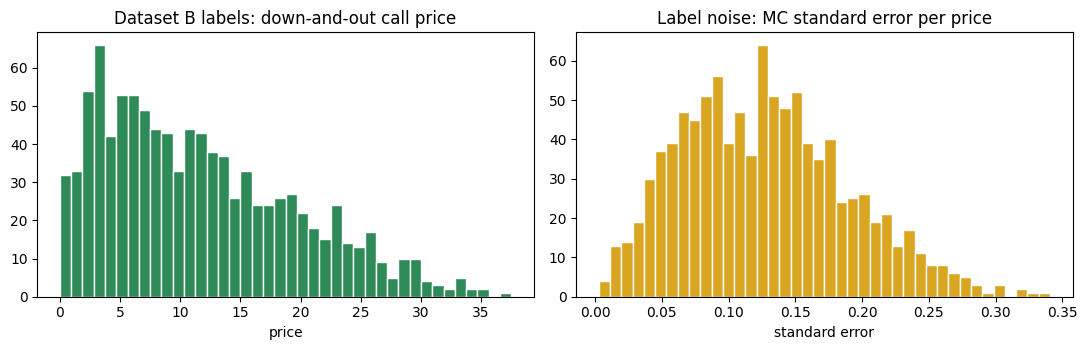

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(y_bar, bins=40, color="seagreen", edgecolor="white")
ax[0].set_title("Dataset B labels: down-and-out call price")
ax[0].set_xlabel("price")
ax[1].hist(se_bar, bins=40, color="goldenrod", edgecolor="white")
ax[1].set_title("Label noise: MC standard error per price")
ax[1].set_xlabel("standard error")
plt.tight_layout()
plt.savefig("figures/fig_q2_labels_barrier.png", dpi=150, bbox_inches="tight")
plt.show()

The label distribution is right-skewed, peaking around three to seven dollars with a long tail of expensive contracts. Knock-out risk trims value relative to a vanilla call, since the knocked-out paths contribute nothing to the average payoff, but outright dead contracts are rare in this design (0.6% below 25 cents): a worthless contract needs a close barrier, high volatility and a long maturity to line up, and that corner of the box is appropriately small under the Latin hypercube. The right panel is the noise profile of the labels: standard errors centre around twelve cents, largest for expensive contracts (payoff variance scales with the payoff) and smallest where knock-out leaves little payoff variance.
## 7. Learning the barrier pricing function

The protocol is identical to Section 4 (same split ratio, same scaling discipline, same model families, same metrics) with one deliberate change in the GPR noise treatment. The tree labels were effectively exact, so a small fixed nugget was enough. The MC labels carry real, known noise, so the GPR kernel now includes a `WhiteKernel` whose level is learned from the data: the GP is told "part of what you see is measurement noise, estimate how much". This gives an elegant self-test, because we know the true answer, the Monte Carlo standard errors recorded at generation time. If the GP is working, its learned noise level should come out close to the average recorded standard error, two numbers obtained by completely different routes.

In [ ]:
idxb_tr, idxb_te = train_test_split(np.arange(N_BAR), test_size=0.2, random_state=SEED)
Xb_tr, Xb_te = X_bar[idxb_tr], X_bar[idxb_te]
yb_tr, yb_te = y_bar[idxb_tr], y_bar[idxb_te]
print(f"train {Xb_tr.shape[0]} rows | test {Xb_te.shape[0]} rows")

t0 = time.perf_counter()
gpr_bar = make_gpr(10, noisy=True)
gpr_bar.fit(Xb_tr, yb_tr)
FIT_GPR_BAR = time.perf_counter() - t0
gpk = gpr_bar.named_steps["gp"].kernel_
print(f"GPR barrier fitted in {FIT_GPR_BAR:.1f} s")
print("  kernel:", gpk)

# learned white-noise level is in normalised-y units; convert back to dollars
noise_dollars = np.sqrt(gpk.k2.noise_level) * yb_tr.std(ddof=1)
print(f"\nGP learned label noise: {noise_dollars:.4f} dollars per price")
print(f"known mean MC standard error (train rows): {se_bar[idxb_tr].mean():.4f} dollars")

ls_bar = pd.Series(gpk.k1.k2.length_scale, index=BAR_COLS, name="length-scale")
display(ls_bar.round(2).to_frame().T)

train 800 rows | test 200 rows


GPR barrier fitted in 53.9 s
  kernel: 3.55**2 * Matern(length_scale=[5.93, 10.5, 26.1, 35.9, 8.25, 20.1, 15.2, 14.7, 44.7, 50.9], nu=2.5) + WhiteKernel(noise_level=0.000323)

GP learned label noise: 0.1419 dollars per price
known mean MC standard error (train rows): 0.1278 dollars


,K,T,r,q,B,v0,theta,kappa,eta,rho
length-scale,5.93,10.54,26.13,35.93,8.25,20.08,15.19,14.66,44.67,50.9


In [ ]:
t0 = time.perf_counter()
mlp_bar = make_mlp_search()
mlp_bar.fit(Xb_tr, yb_tr)
FIT_MLP_BAR = time.perf_counter() - t0
print(f"MLP barrier: grid search done in {FIT_MLP_BAR:.1f} s")
print("  best:", mlp_bar.best_params_, f"| CV RMSE {-mlp_bar.best_score_:.4f}")

pred_bar = {"GPR": gpr_bar.predict(Xb_te), "MLP": mlp_bar.predict(Xb_te)}
res_bar = pd.DataFrame({("Barrier DO call", k): metric_row(yb_te, v)
                        for k, v in pred_bar.items()}).T
res_bar.index.names = ["target", "model"]
res_bar.to_csv("figures/table_q2_metrics_barrier.csv")
display(res_bar.round(4))
print(f"context: label std {yb_te.std(ddof=1):.2f} dollars | "
      f"mean MC standard error of test labels {se_bar[idxb_te].mean():.4f} dollars")

MLP barrier: grid search done in 38.9 s
  best: {'regressor__nn__alpha': 0.001, 'regressor__nn__hidden_layer_sizes': (128, 128)} | CV RMSE 1.0363


RMSE     MAE      R2   NRMSE  max |error|
target          model                                             
Barrier DO call GPR    0.3197  0.2321  0.9985  0.0387       1.7830
                MLP    0.9793  0.7330  0.9859  0.1186       4.2314

context: label std 8.28 dollars | mean MC standard error of test labels 0.1250 dollars


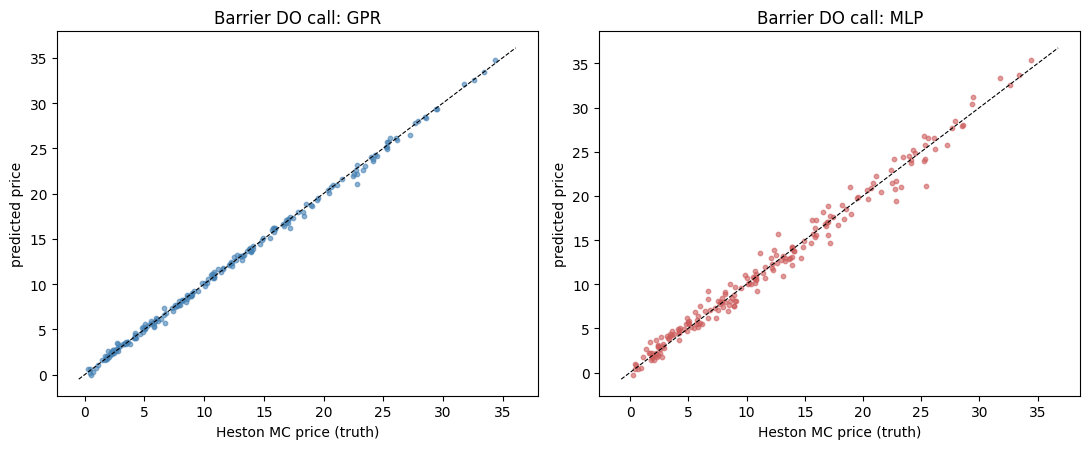

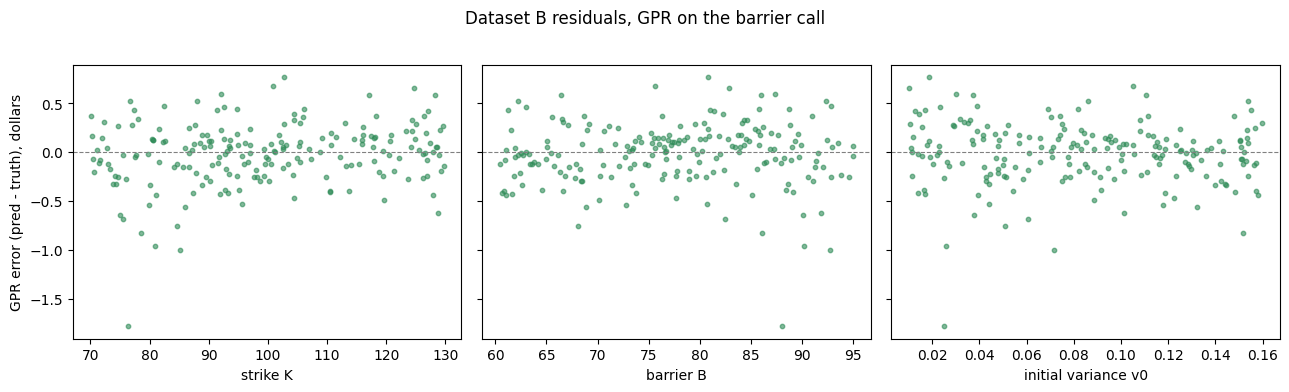

GPR residual std 0.3200 vs mean test-label MC SE 0.1250


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for axx, (name, pred) in zip(ax, pred_bar.items()):
    axx.scatter(yb_te, pred, s=10, alpha=0.6,
                color="steelblue" if name == "GPR" else "indianred")
    lim = [min(0, pred.min()) - 0.5, max(yb_te.max(), pred.max()) * 1.04]
    axx.plot(lim, lim, "k--", lw=0.8)
    axx.set_title(f"Barrier DO call: {name}")
    axx.set_xlabel("Heston MC price (truth)")
    axx.set_ylabel("predicted price")
plt.tight_layout()
plt.savefig("figures/fig_q2_pred_vs_true_barrier.png", dpi=150, bbox_inches="tight")
plt.show()

resid_b = pred_bar["GPR"] - yb_te
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for axx, col, lab in zip(ax, [0, 4, 5], ["strike K", "barrier B", "initial variance v0"]):
    axx.scatter(Xb_te[:, col], resid_b, s=10, alpha=0.6, color="seagreen")
    axx.axhline(0, color="grey", lw=0.8, ls="--")
    axx.set_xlabel(lab)
ax[0].set_ylabel("GPR error (pred - truth), dollars")
fig.suptitle("Dataset B residuals, GPR on the barrier call", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_q2_residuals_barrier.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"GPR residual std {resid_b.std(ddof=1):.4f} vs mean test-label MC SE {se_bar[idxb_te].mean():.4f}")

The picture is accurate but visibly noisier than dataset A, and it should be: two effects stack against it. First, the labels are noisy; the measured RMSE mixes true model error with label noise (they add in quadrature), so no model can score below that floor. Second, and quantitatively more important, the function is harder. The GPR test RMSE of about 0.32 is some 2.6 times the average label standard error of 0.125, and removing the noise floor in quadrature still leaves roughly 0.29 of genuine approximation error. The binding constraint is therefore learning a 10-dimensional surface with a kinked knock-out region from 800 points, not the Monte Carlo noise. The practical reading: to improve this surrogate, buy more training rows first; more paths per label only starts to pay once model error approaches the noise floor.

GPR again beats the MLP, for the same small-data reason as before, now amplified: 800 training points in 10 dimensions is a sparse design, the regime where a GP's smoothness prior earns its keep and a flexible network is most tempted to overfit. The residual panels show no structure in strike or initial variance; against the barrier there is a mild widening toward high $B$, and the few residuals beyond a dollar belong to contracts hugging the barrier, where knock-out probabilities, and therefore prices, change fastest, the steepest and least smooth corner of this surface.

As for dataset A, we close with a slice of the learned function: price against strike at fixed mid-box Heston parameters, with fresh Monte Carlo prices (and their 2-standard-error bars) as the ground truth. The GPR band here is a predictive band for a new MC measurement, so it includes the learned label noise; ideally it should be about as wide as the error bars it is trying to cover.

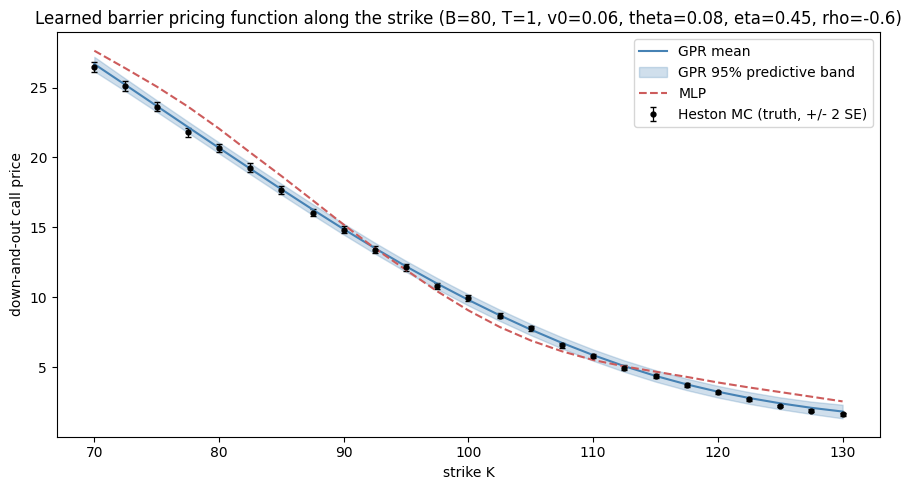

share of fresh MC dots inside the GPR 95% band: 100%


In [ ]:
K_grid_b = np.linspace(70, 130, 25)
slice_b = dict(T=1.0, r=0.03, q=0.02, B=80.0, v0=0.06, theta=0.08,
               kappa=2.0, eta=0.45, rho=-0.6)
mc_dots = np.array([heston_mc_do_call(K=K, seed=SEED + 7000 + i, return_se=True, **slice_b)
                    for i, K in enumerate(K_grid_b)])

X_slice_b = np.column_stack([K_grid_b] + [np.full_like(K_grid_b, slice_b[c]) for c in BAR_COLS[1:]])
scb, gpb = gpr_bar.named_steps["sc"], gpr_bar.named_steps["gp"]
gp_mean_b, gp_sd_b = gpb.predict(scb.transform(X_slice_b), return_std=True)
mlp_slice_b = mlp_bar.predict(X_slice_b)

plt.figure(figsize=(9, 5))
plt.errorbar(K_grid_b, mc_dots[:, 0], yerr=2 * mc_dots[:, 1], fmt="ko", ms=3.5,
             lw=0.9, capsize=2.5, label="Heston MC (truth, +/- 2 SE)")
plt.plot(K_grid_b, gp_mean_b, color="steelblue", lw=1.5, label="GPR mean")
plt.fill_between(K_grid_b, gp_mean_b - 1.96 * gp_sd_b, gp_mean_b + 1.96 * gp_sd_b,
                 color="steelblue", alpha=0.25, label="GPR 95% predictive band")
plt.plot(K_grid_b, mlp_slice_b, color="indianred", lw=1.5, ls="--", label="MLP")
plt.xlabel("strike K")
plt.ylabel("down-and-out call price")
plt.title("Learned barrier pricing function along the strike "
          "(B=80, T=1, v0=0.06, theta=0.08, eta=0.45, rho=-0.6)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/fig_q2_slice_barrier.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"share of fresh MC dots inside the GPR 95% band: "
      f"{np.mean(np.abs(mc_dots[:, 0] - gp_mean_b) <= 1.96 * gp_sd_b):.0%}")



## 8. Computational speedup

 The table below times every pricer on the same task, pricing one option (per-option figures for the surrogates are measured by batch prediction over the test set divided by its size, which is how a surrogate would be used; the engines are timed per call). One-off costs, generating the training data and fitting the model, are reported separately, and the break-even column answers the natural objection "but the dataset cost minutes": it is the number of pricings after which the surrogate has repaid that investment.

In [ ]:
def time_per_call(fn, reps):
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    return (time.perf_counter() - t0) / reps

# engines, per option
t_tree = time_per_call(lambda: crr_binomial("p", S0, 102.0, 1.1, 0.04, 0.02, 0.3, N=N_STEPS), 10)
t_mc = time_per_call(lambda: heston_mc_do_call(seed=123, **HESTON_DEMO), 4)

# surrogates, per option (batch over the held-out designs)
t_gpr_am = time_per_call(lambda: gpr_put.predict(Xam_te), 20) / len(Xam_te)
t_mlp_am = time_per_call(lambda: mlp_put.predict(Xam_te), 20) / len(Xam_te)
t_gpr_bar = time_per_call(lambda: gpr_bar.predict(Xb_te), 20) / len(Xb_te)
t_mlp_bar = time_per_call(lambda: mlp_bar.predict(Xb_te), 20) / len(Xb_te)

rows = []
rows.append(["American (tree)", "binomial tree N=1000", t_tree * 1e3, 1.0, 0.0, np.nan])
for name, tp, fit_t in [("GPR", t_gpr_am, FIT_GPR_PUT), ("MLP", t_mlp_am, FIT_MLP_PUT)]:
    oneoff = GEN_TIME_AM / 2 + fit_t        # half the generation time: put labels only
    rows.append(["American (tree)", f"{name} surrogate", tp * 1e3, t_tree / tp,
                 oneoff, oneoff / (t_tree - tp)])
rows.append(["Barrier (Heston MC)", "Euler MC 20k paths", t_mc * 1e3, 1.0, 0.0, np.nan])
for name, tp, fit_t in [("GPR", t_gpr_bar, FIT_GPR_BAR), ("MLP", t_mlp_bar, FIT_MLP_BAR)]:
    oneoff = GEN_TIME_BAR + fit_t
    rows.append(["Barrier (Heston MC)", f"{name} surrogate", tp * 1e3, t_mc / tp,
                 oneoff, oneoff / (t_mc - tp)])

speed = pd.DataFrame(rows, columns=["pricing problem", "pricer", "ms per option",
                                    "speedup factor", "one-off cost (s)",
                                    "break-even (# pricings)"])
speed = speed.set_index(["pricing problem", "pricer"])
speed["speedup factor"] = speed["speedup factor"].round(0)
speed["break-even (# pricings)"] = speed["break-even (# pricings)"].round(0)
speed.to_csv("figures/table_q2_speedup.csv")
display(speed.round(4))

ms per option  speedup factor  one-off cost (s)  break-even (# pricings)
pricing problem     pricer                                                                                        
American (tree)     binomial tree N=1000        13.0026             1.0            0.0000                      NaN
                    GPR surrogate                0.0684           190.0          149.0973                  11527.0
                    MLP surrogate                0.0053          2454.0           64.9575                   4998.0
Barrier (Heston MC) Euler MC 20k paths         236.4015             1.0            0.0000                      NaN
                    GPR surrogate                0.0697          3391.0          315.2150                   1334.0
                    MLP surrogate                0.0101         23358.0          300.2587                   1270.0

The headline numbers: the MLP prices an American option about 2,500 times faster than the tree and a barrier option more than 20,000 times faster than the Monte Carlo; GPR sits roughly an order of magnitude above the MLP in cost (its prediction touches every training point through the kernel) but still beats the two engines by factors of about 190 and 3,400. Against the slow engine, the entire offline investment of the barrier pipeline, around five minutes of simulation plus the fits, is repaid after about 1,300 pricings, which a single calibration run or a risk-system revaluation of a book consumes immediately. That is the economic case for surrogate pricing in one row: pay minutes once, then price in microseconds forever, with the accuracy documented in Sections 4 and 7.

The speedup is largest exactly where the engine is slowest (the Monte Carlo), but so is the accuracy cost: those labels are noisy and their surface is higher-dimensional, so the barrier surrogate is the less precise of the two. The speed is real, but it arrives together with label noise and problem difficulty, not for free.

## 9. Comparing the two pipelines: binomial tree versus Monte Carlo

The two pipelines were run completely separately, each with its own engine, dataset, fits and evaluation. The table and figure below put their test results side by side. Surrogate timings for the American rows are measured on the put models; the call models have identical prediction cost because they share architecture and training size.

RMSE     MAE      R2   NRMSE  max |error|  engine ms/option  surrogate ms/option  speedup
target          model                                                                                             
American put    GPR    0.0877  0.0402  0.9999  0.0079       0.7317           13.0026               0.0684    190.0
                MLP    0.4276  0.3003  0.9985  0.0386       2.3043           13.0026               0.0053   2454.0
American call   GPR    0.0689  0.0372  1.0000  0.0068       0.4114           13.0026               0.0684    190.0
                MLP    0.3196  0.2328  0.9990  0.0318       1.5028           13.0026               0.0053   2454.0
Barrier DO call GPR    0.3197  0.2321  0.9985  0.0387       1.7830          236.4015               0.0697   3391.0
                MLP    0.9793  0.7330  0.9859  0.1186       4.2314          236.4015               0.0101  23358.0

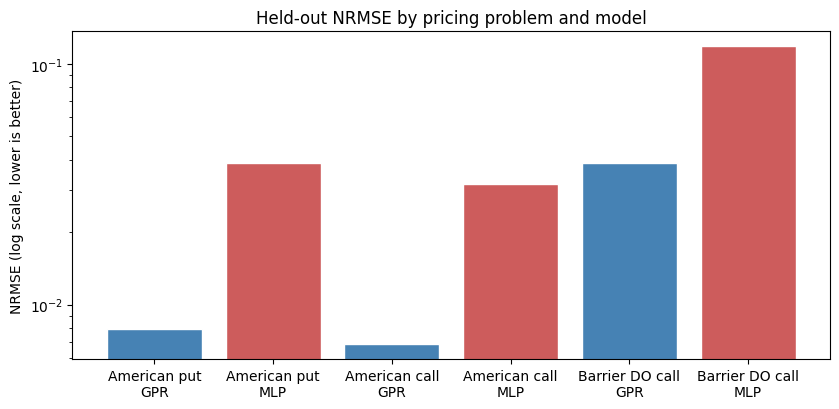

In [ ]:
summary = pd.concat([res_am, res_bar])
summary["engine ms/option"] = [t_tree * 1e3] * 4 + [t_mc * 1e3] * 2
summary["surrogate ms/option"] = [t_gpr_am * 1e3, t_mlp_am * 1e3] * 2 + [t_gpr_bar * 1e3, t_mlp_bar * 1e3]
summary["speedup"] = (summary["engine ms/option"] / summary["surrogate ms/option"]).round(0)
summary.to_csv("figures/table_q2_summary.csv")
display(summary.round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.2))
plot_df = summary.reset_index()
labels = plot_df["target"] + "\n" + plot_df["model"]
colors = ["steelblue" if m == "GPR" else "indianred" for m in plot_df["model"]]
ax.bar(labels, plot_df["NRMSE"], color=colors, edgecolor="white")
ax.set_yscale("log")
ax.set_ylabel("NRMSE (log scale, lower is better)")
ax.set_title("Held-out NRMSE by pricing problem and model")
plt.tight_layout()
plt.savefig("figures/fig_q2_summary_nrmse.png", dpi=150, bbox_inches="tight")
plt.show()